<a href="https://colab.research.google.com/github/GelsonRibeiroJr/telecom-x-churn-analysis/blob/main/TelecomX_BR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracão

In [29]:
import requests
import pandas as pd

In [30]:
url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/refs/heads/main/TelecomX_Data.json'
response = requests.get(url)
data = response.json()
df = pd.DataFrame(data)
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [31]:
df = pd.json_normalize(data)
df

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


#🔧 Transformação

In [5]:
df.info ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

**VERIFICAÇÕES**

            1.Verificando valores unicos

In [6]:
for col in df.columns:
    print (f'{col}: {df[col].unique()}')

    if df[col].nunique() < 50:
        print('Valores únicos:')
        print(df[col].unique())
        print('-' * 50)


customerID: ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
Churn: ['No' 'Yes' '']
Valores únicos:
['No' 'Yes' '']
--------------------------------------------------
customer.gender: ['Female' 'Male']
Valores únicos:
['Female' 'Male']
--------------------------------------------------
customer.SeniorCitizen: [0 1]
Valores únicos:
[0 1]
--------------------------------------------------
customer.Partner: ['Yes' 'No']
Valores únicos:
['Yes' 'No']
--------------------------------------------------
customer.Dependents: ['Yes' 'No']
Valores únicos:
['Yes' 'No']
--------------------------------------------------
customer.tenure: [ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 37 49 66
 67 20 43 59 12 27  2 25 29 14 35 64 39 40  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 51 31 36 17 18 38 42
  0]
phone.PhoneService: ['Yes' 'No']
Valores únicos:
['Yes' 'No']
----------------------------------------------

**2. Valores Duplicados**

In [7]:
print("Numero de duplicados", df.duplicated().sum())


Numero de duplicados 0


**3. Valores Nulos**

In [8]:
print("Numero de nulos \n", df.isnull().sum())

Numero de nulos 
 customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
account.Charges.Total        0
dtype: int64


**4. Vazios ou em Branco**

In [9]:
df.apply(lambda x: x.astype(str).str.strip() == '').sum()

,0
customerID,0
Churn,224
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


**TRANSFORMAÇÕES**

1. Alterando a coluna "account.Charges.Total" para Float

In [32]:
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')

In [33]:
df= df[df['Churn'].str.strip() != '']
print("Número de filas depois de eliminar as vazias em 'Churn':", len(df))

Número de filas depois de eliminar as vazias em 'Churn': 7043


3.Verificação de vazias ou em branco

In [12]:
df.apply(lambda x: x.astype(str).str.strip() == '').sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [13]:
df= df[df['Churn'].str.strip() != '']
print("Número de filas depois de eliminar as vazias em 'Churn':", len(df))

Número de filas depois de eliminar as vazias em 'Churn': 7043


3.Verificação de vazias ou em branco

In [14]:
df.apply(lambda x: x.astype(str).str.strip() == '').sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [15]:
print("Numero de Nulos \n", df.isnull().sum())

Numero de Nulos 
 customerID                    0
Churn                         0
customer.gender               0
customer.SeniorCitizen        0
customer.Partner              0
customer.Dependents           0
customer.tenure               0
phone.PhoneService            0
phone.MultipleLines           0
internet.InternetService      0
internet.OnlineSecurity       0
internet.OnlineBackup         0
internet.DeviceProtection     0
internet.TechSupport          0
internet.StreamingTV          0
internet.StreamingMovies      0
account.Contract              0
account.PaperlessBilling      0
account.PaymentMethod         0
account.Charges.Monthly       0
account.Charges.Total        11
dtype: int64


In [34]:
df = df.dropna(subset=['account.Charges.Total'])

In [17]:
print("Numero de Nulos \n", df.isnull().sum())

Numero de Nulos 
 customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
account.Charges.Total        0
dtype: int64


**Opcional**

In [35]:
df['contas_diarias'] = df['account.Charges.Monthly'] / 30
df

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,contas_diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,Yes,No,No,One year,No,Mailed check,55.15,742.90,1.838333
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70,2.836667
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75,1.676667
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65,2.261667


**Padronização**

In [36]:
colunas = {
    'customerID': 'id',
    'customer.gender': 'genero',
    'customer.SeniorCitizen': 'tem +60',
    'customer.Partner': 'possui_parceiro',
    'customer.Dependents': 'possui_dependentes',
    'customer.tenure': 'tempo_contrato',
    'phone.PhoneService': 'servico_telefone',
    'phone.MultipleLines': 'multiplas_linhas',
    'internet.InternetService': 'tipo_internet',
    'internet.OnlineSecurity': 'seguranca_online',
    'internet.OnlineBackup': 'backup_online',
    'internet.DeviceProtection': 'protecao_dispositivo',
    'internet.TechSupport': 'suporte_tecnico',
    'internet.StreamingTV': 'streaming_tv',
    'internet.StreamingMovies': 'streaming_filmes',
    'account.Contract': 'tipo_contrato',
    'account.PaperlessBilling': 'fatura_digital',
    'account.PaymentMethod': 'metodo_pagamento',
    'account.Charges.Monthly': 'valor_mensal',
    'account.Charges.Total': 'total_cobrado'
}
df = df.rename(columns= colunas)
df

,id,Churn,genero,tem +60,possui_parceiro,possui_dependentes,tempo_contrato,servico_telefone,multiplas_linhas,tipo_internet,...,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,valor_mensal,total_cobrado,contas_diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,Yes,No,No,One year,No,Mailed check,55.15,742.90,1.838333
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70,2.836667
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75,1.676667
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65,2.261667


Padronizar para **Português**

In [37]:
df['Churn'] = df['Churn'].replace({'No': 'Não', 'Yes': 'Sim'})
df['genero'] = df['genero'].replace({'Female': 'Feminino', 'Male': 'Masculino'})
df['possui_parceiro'] = df['possui_parceiro'].replace({'Yes': 'Sim', 'No': 'Não'})
df['possui_dependentes'] = df['possui_dependentes'].replace({'Yes': 'Sim', 'No': 'Não'})
df['servico_telefone'] = df['servico_telefone'].replace({'Yes': 'Sim', 'No': 'Não'})
df['multiplas_linhas'] = df['multiplas_linhas'].replace({'No': 'Não', 'Yes': 'Sim', 'No phone service': 'Sem serviço de telefone'})
df['tipo_internet'] = df['tipo_internet'].replace({'No': 'Não'})
df.head()

,id,Churn,genero,tem +60,possui_parceiro,possui_dependentes,tempo_contrato,servico_telefone,multiplas_linhas,tipo_internet,...,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,valor_mensal,total_cobrado,contas_diarias
0,0002-ORFBO,Não,Feminino,0,Sim,Sim,9,Sim,Não,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,Não,Masculino,0,Não,Não,9,Sim,Sim,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,Sim,Masculino,0,Não,Não,4,Sim,Não,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Sim,Masculino,1,Sim,Não,13,Sim,Não,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Sim,Feminino,1,Sim,Não,3,Sim,Não,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


In [38]:
columns_to_translate = ['seguranca_online', 'backup_online', 'protecao_dispositivo', 'suporte_tecnico', 'streaming_tv', 'streaming_filmes']
mapping = {'No': 'Não', 'Yes': 'Sim', 'No internet service': 'Sem serviço de internet'}
for col in columns_to_translate:
    df[col] = df[col].replace(mapping)

In [39]:
df['tipo_contrato'] = df['tipo_contrato'].replace({'One year': 'Anual', 'Month-to-month': 'Mensal', 'Two year': 'Bienal'})

In [40]:
df['fatura_digital'] = df['fatura_digital'].replace({'Yes': 'Sim', 'No': 'Não'})

In [41]:
df['metodo_pagamento'] = df['metodo_pagamento'].replace({
    'Mailed check': 'Cheque enviado',
    'Electronic check': 'Cheque eletrônico',
    'Credit card (automatic)': 'Cartão de crédito (automático)',
    'Bank transfer (automatic)': 'Transferência bancária (automática)'
})

In [25]:
df

,id,Churn,genero,tem +60,possui_parceiro,possui_dependentes,tempo_contrato,servico_telefone,multiplas_linhas,tipo_internet,...,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,valor_mensal,total_cobrado,contas_diarias
0,0002-ORFBO,Não,Feminino,0,Sim,Sim,9,Sim,Não,DSL,...,Não,Sim,Sim,Não,Anual,Sim,Cheque enviado,65.60,593.30,2.186667
1,0003-MKNFE,Não,Masculino,0,Não,Não,9,Sim,Sim,DSL,...,Não,Não,Não,Sim,Mensal,Não,Cheque enviado,59.90,542.40,1.996667
2,0004-TLHLJ,Sim,Masculino,0,Não,Não,4,Sim,Não,Fiber optic,...,Sim,Não,Não,Não,Mensal,Sim,Cheque eletrônico,73.90,280.85,2.463333
3,0011-IGKFF,Sim,Masculino,1,Sim,Não,13,Sim,Não,Fiber optic,...,Sim,Não,Sim,Sim,Mensal,Sim,Cheque eletrônico,98.00,1237.85,3.266667
4,0013-EXCHZ,Sim,Feminino,1,Sim,Não,3,Sim,Não,Fiber optic,...,Não,Sim,Sim,Não,Mensal,Sim,Cheque enviado,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,Não,Feminino,0,Não,Não,13,Sim,Não,DSL,...,Não,Sim,Não,Não,Anual,Não,Cheque enviado,55.15,742.90,1.838333
7263,9992-RRAMN,Sim,Masculino,0,Sim,Não,22,Sim,Sim,Fiber optic,...,Não,Não,Não,Sim,Mensal,Sim,Cheque eletrônico,85.10,1873.70,2.836667
7264,9992-UJOEL,Não,Masculino,0,Não,Não,2,Sim,Não,DSL,...,Não,Não,Não,Não,Mensal,Sim,Cheque enviado,50.30,92.75,1.676667
7265,9993-LHIEB,Não,Masculino,0,Sim,Sim,67,Sim,Não,DSL,...,Sim,Sim,Não,Sim,Bienal,Não,Cheque enviado,67.85,4627.65,2.261667


#📊 Carga e análise

1.Analise Descritiva

In [26]:
df.describe()


,tem +60,tempo_contrato,valor_mensal,total_cobrado,contas_diarias
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441,2.159940
std,0.368844,24.545260,30.085974,2266.771362,1.002866
min,0.000000,1.000000,18.250000,18.800000,0.608333
25%,0.000000,9.000000,35.587500,401.450000,1.186250
50%,0.000000,29.000000,70.350000,1397.475000,2.345000
75%,0.000000,55.000000,89.862500,3794.737500,2.995417
max,1.000000,72.000000,118.750000,8684.800000,3.958333


2. Distribuição de Evasão

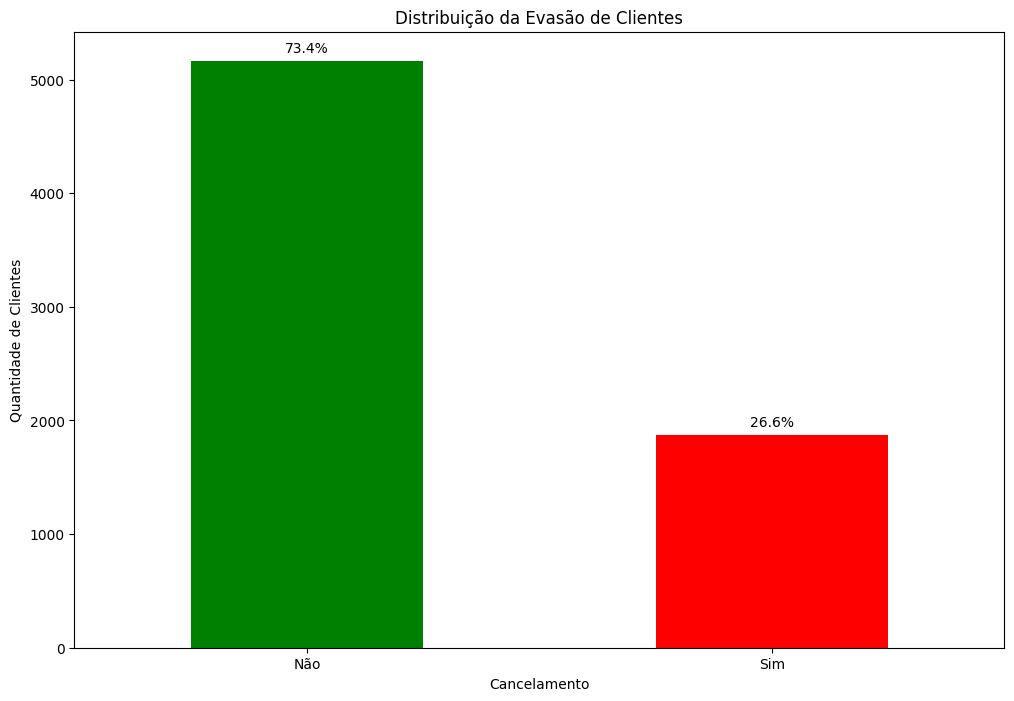

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

churn_counts = df['Churn'].value_counts()
churn_percentages = (churn_counts / len(df)) * 100

# Definindo cores por categoria
colors = ['green' if label == 'Não' else 'red' for label in churn_counts.index]

ax = churn_counts.plot(kind='bar', color=colors)

plt.title('Distribuição da Evasão de Clientes')
plt.xlabel('Cancelamento')
plt.ylabel('Quantidade de Clientes')
plt.xticks(rotation=0)

for i, percentage in enumerate(churn_percentages):
    ax.text(
        i,
        churn_counts.iloc[i] + 50,
        f'{percentage:.1f}%',
        ha='center',
        va='bottom'
    )

plt.show()

3. Contagem de Evasão por Variáveis Categóricas.

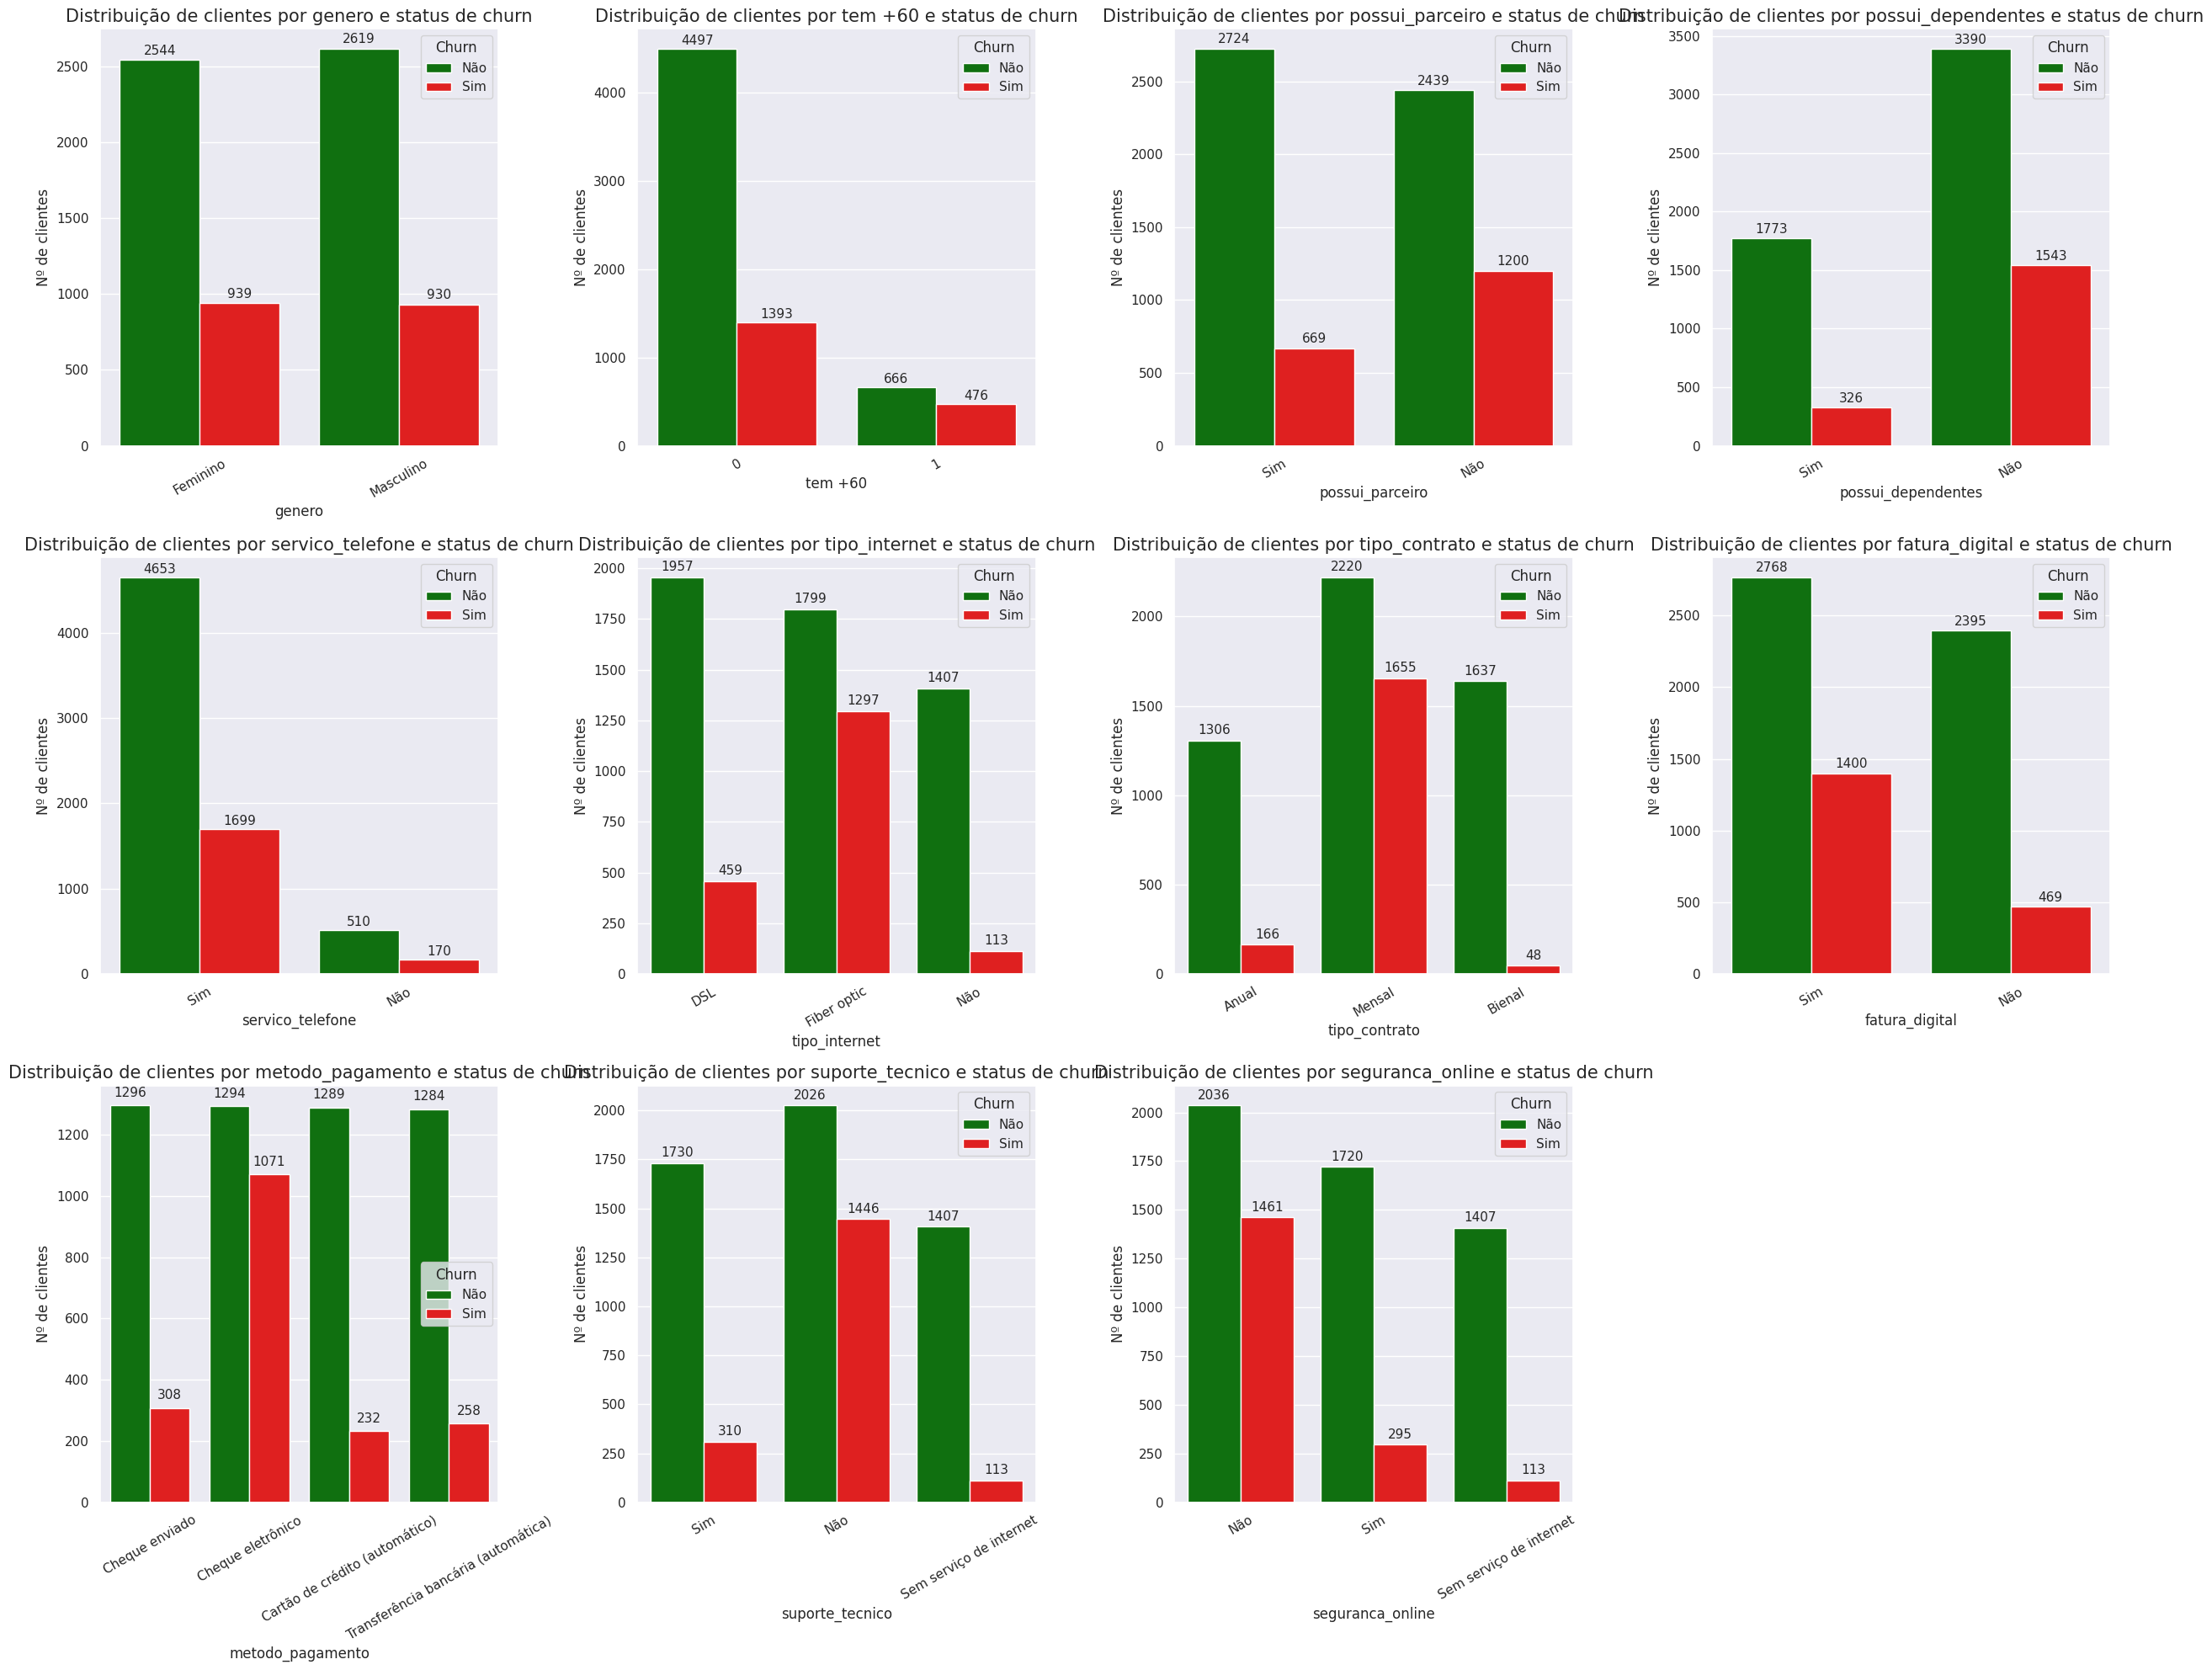

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# Subconjunto apenas com churn válido (evita distorções)
df_churn = df[df['Churn'].str.strip() != '']

# Variáveis categóricas (incluindo serviços adicionais relevantes)
variaveis_categoricas = [
    'genero',
    'tem +60',
    'possui_parceiro',
    'possui_dependentes',
    'servico_telefone',
    'tipo_internet',
    'tipo_contrato',
    'fatura_digital',
    'metodo_pagamento',
    'suporte_tecnico',
    'seguranca_online'
]

lista_variaveis_categoricas = list(enumerate(variaveis_categoricas))

sns.set(rc={'figure.figsize': (25, 20)})

for i in lista_variaveis_categoricas:
    plt.subplot(3, 4, i[0] + 1)

    ax = sns.countplot(
        data=df_churn,
        x=i[1],
        hue='Churn',
        palette={'Não': 'green', 'Sim': 'red'}
    )

    ax.set_title(f'Distribuição de clientes por {i[1]} e status de churn', fontsize=15)
    ax.set_ylabel('Nº de clientes', fontsize=12)
    ax.set_xlabel(i[1], fontsize=12)
    ax.tick_params(axis='x', rotation=30)

    # Rótulos de dados
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.text(
                p.get_x() + p.get_width() / 2.,
                height + 20,
                f'{int(height)}',
                ha='center',
                va='bottom',
                fontsize=11
            )

plt.tight_layout()
plt.show()

1. Tempo de contrato (tenure × churn) - Clientes que evadem têm tenure significativamente menor

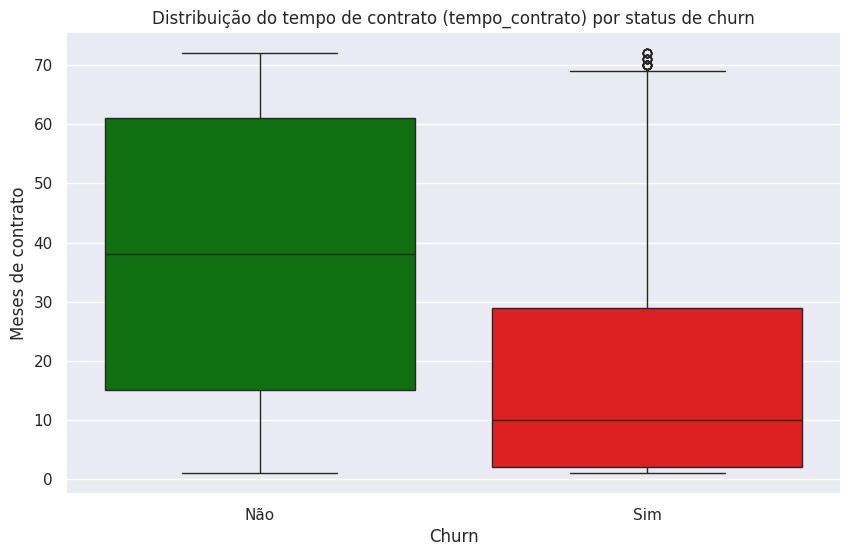

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_churn,
    x='Churn',
    y='tempo_contrato',
    hue='Churn',
    palette={'Não': 'green', 'Sim': 'red'},
    legend=False
)

plt.title('Distribuição do tempo de contrato (tempo_contrato) por status de churn')
plt.xlabel('Churn')
plt.ylabel('Meses de contrato')

plt.show()

2. Valor mensal × Churn

* Churn mais alto em valores mensais elevados

* Percepção de custo pesa

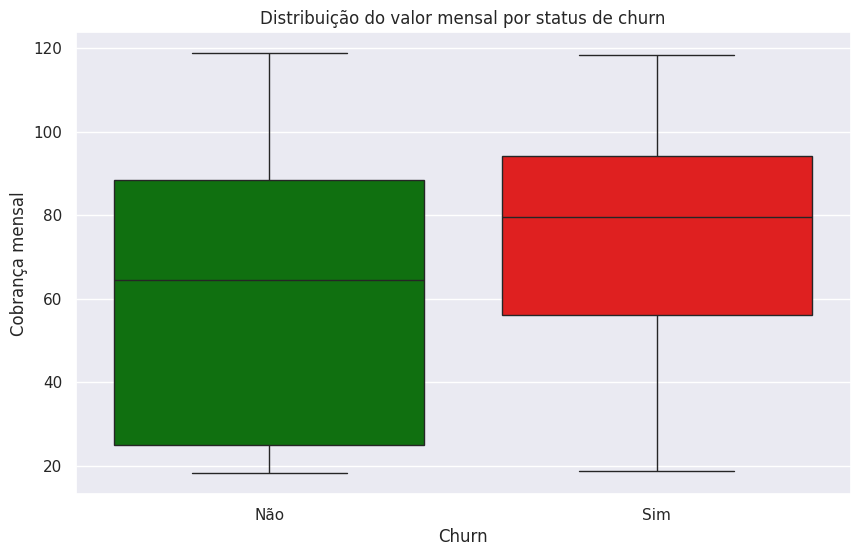

In [47]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_churn,
    x='Churn',
    y='valor_mensal',
    hue='Churn',
    palette={'Não': 'green', 'Sim': 'red'},
    legend=False
)

plt.title('Distribuição do valor mensal por status de churn')
plt.xlabel('Churn')
plt.ylabel('Cobrança mensal')

plt.show()

#📄Relatorio Final

Com base nos gráficos que geramos, podemos extrair os seguintes insights para a análise de Churn da nossa empresa.

*Taxa Geral de Churn:* Observamos que a empresa tem uma taxa de Churn significativa. Uma porcentagem considerável de clientes está cancelando o serviço, o que justifica uma análise aprofundada.

*Tempo de Contrato:* Clientes que cancelam o serviço tendem a ter um tempo de contrato significativamente menor em comparação com aqueles que não cancelam. Isso sugere que a insatisfação ou a decisão de sair ocorre mais cedo na jornada do cliente. Clientes de longa data são mais fiéis ao serviço.

*Valor Mensal:* Clientes que cancelam o serviço geralmente têm cobranças mensais mais altas do que os que permanecem. Isso pode indicar que a percepção de valor pelo preço pago é um fator crítico para a decisão de Churn; talvez os clientes com contas mais caras sintam que não estão recebendo um retorno adequado pelo investimento.

*Tipo de Contrato:* Esta é uma das variáveis mais impactantes. Clientes com contratos 'Mensais' apresentam uma taxa de Churn dramaticamente maior em comparação com contratos 'Anuais' ou 'Bienais'. Contratos de longo prazo demonstram maior lealdade e estabilidade.

*Serviços de Internet:* Clientes com serviço 'Fiber optic' tendem a ter uma taxa de Churn mais alta em comparação com 'DSL'. Aqueles sem serviço de internet também têm uma taxa de Churn muito baixa, indicando que a complexidade ou expectativa de serviços de internet de alta velocidade pode influenciar a decisão de cancelar.

*Método de Pagamento:* O método de pagamento 'Cheque eletrônico' parece estar associado a uma taxa de Churn mais alta. Isso pode estar ligado ao tipo de cliente que escolhe esse método, ou talvez a problemas de conveniência ou segurança.

*Serviços Adicionais* (Segurança Online, Suporte Técnico, Backup Online, Proteção de Dispositivo, Streaming TV/Filmes): Clientes que não utilizam serviços adicionais como 'seguranca_online' e 'suporte_tecnico' mostram uma taxa de Churn mais elevada. Isso sugere que esses serviços podem atuar como fatores de retenção, pois clientes que os utilizam se sentem mais engajados e seguros com a empresa.

*Fatura Digital:* Clientes com 'fatura_digital' podem apresentar um Churn ligeiramente maior em alguns casos. Isso pode estar relacionado a um perfil de cliente mais jovem e engajado digitalmente, que também pode ser mais propenso a buscar outras ofertas.

*Parceiro e Dependentes:* Clientes sem parceiro ou dependentes tendem a cancelar mais. Isso indica que clientes com laços familiares podem ter maior necessidade de estabilidade nos serviços e, consequentemente, menor propensão ao Churn.

Em resumo, esses insights sugerem que o foco na retenção deve ser dado a clientes com menor tempo de contrato, que pagam contas mensais mais altas, possuem contratos mensais, utilizam fibra óptica, pagam via cheque eletrônico e/ou não contratam serviços adicionais de segurança ou suporte.

# **Estratégias**

Com base nos insights que tivemos através das nossas análises, podemos propor algumas estratégias focadas para conter a taxa de churn e aumentar a retenção de clientes:

**1. Programas de Engajamento para Clientes Novatos e de Curto Prazo:**

Clientes que cancelam têm tempo de contrato significativamente menor.
Portanto, implementar um programa de 'onboarding' robusto nos primeiros 3-6 meses de contrato. Isso pode incluir check-ins proativos, ofertas especiais de boas-vindas, suporte prioritário e materiais educativos para garantir que o cliente esteja aproveitando ao máximo o serviço e oferecer incentivos para migrar para contratos de prazo mais longo após o período inicial.

**2. Revisão de Precificação e Percepção de Valor:**

Churn mais alto em valores mensais elevados, com isso podemos realizar uma análise da estrutura de preços dos planos mais caros. É essencial garantir que o cliente perceba o valor correspondente ao que está pagando. Campanhas de comunicação devem reforçar os benefícios e funcionalidades exclusivas desses planos. Considerar programas de fidelidade que ofereçam descontos ou benefícios adicionais progressivamente.

**3. Incentivo a Contratos de Longo Prazo:**

Clientes com contratos 'Mensais' apresentam uma taxa de Churn dramaticamente maior. Como estratégia preciamos fortalecer a oferta e a promoção de contratos anuais e bienais, destacando os benefícios de economia (descontos significativos), estabilidade de preço e acesso a serviços premium. Treinar a equipe de vendas e atendimento para educar os clientes sobre as vantagens de um compromisso de longo prazo.

**4. Melhoria Contínua para Clientes de Fibra Óptica:**

Clientes com serviço 'Fiber optic' tendem a ter uma taxa de Churn mais alta.
Devemos Investigar profundamente as razões específicas de insatisfação entre os usuários de fibra. Pode ser qualidade do serviço, suporte técnico, ou expectativas não atendidas. Aprimorar o suporte técnico especializado para fibra, garantir a estabilidade da conexão e talvez oferecer upgrades de velocidade ou equipamentos mais novos para reforçar o valor.

**5. Otimização dos Métodos de Pagamento:**

O método de pagamento 'Cheque eletrônico' parece estar associado a uma taxa de Churn mais alta. Entender o perfil dos clientes que usam cheque eletrônico e se existem problemas de usabilidade ou segurança com esse método. Incentivar a migração para métodos de pagamento automático (cartão de crédito, débito em conta) que geralmente indicam maior conveniência e, consequentemente, menor churn, através de pequenos incentivos ou bônus.

**6. Promoção Ativa de Serviços Agregados:**

Clientes que não utilizam serviços adicionais (segurança online, suporte técnico) mostram uma taxa de Churn mais elevada. Aumentar a conscientização e o valor percebido dos serviços como segurança online e suporte técnico. Oferecer testes gratuitos ou pacotes promocionais combinando-os com o plano principal. Mostrar como esses serviços protegem e facilitam a vida do cliente, atuando como verdadeiros 'ancoradores' da retenção.

**7. Estratégias para Clientes Individuais/Sem Dependentes:**

Clientes sem parceiro ou dependentes tendem a cancelar mais.
Vamos criar ofertas e comunicações segmentadas para este perfil, focando em flexibilidade, benefícios individuais, e talvez opções que se adequem a estilos de vida mais dinâmicos. Construir um senso de comunidade ou pertencimento, se aplicável, para clientes que não têm 'laços familiares' diretos com o serviço.
Ao focar nessas áreas, a empresa pode não apenas reduzir a taxa de Churn, mas também fortalecer o relacionamento com seus clientes e aumentar a fidelidade a longo prazo.